In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../DataSets/car_price_prediction.csv")
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 195.4 KB


In [6]:
df.shape

(2500, 10)

In [7]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


<Axes: >

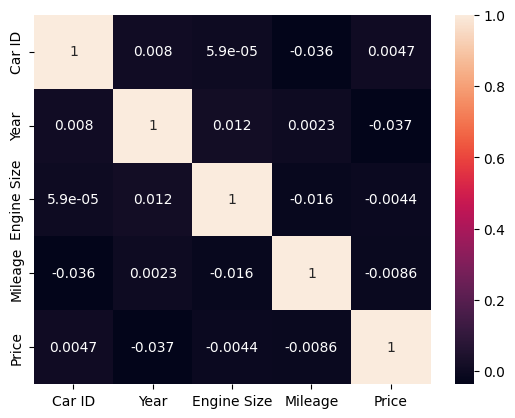

In [8]:
# EDA
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [9]:
df["Transmission"].value_counts()

Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64

In [10]:
df["Fuel Type"].value_counts()

Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64

In [11]:
df["Brand"].value_counts()

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

In [13]:
df["Condition"].value_counts()

Condition
Used        855
Like New    836
New         809
Name: count, dtype: int64

In [12]:
# One hot encoding for Transmission column
df = pd.get_dummies(df, columns=["Transmission"], drop_first=True)
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Mileage,Condition,Price,Model,Transmission_Manual
0,1,Tesla,2016,2.3,Petrol,114832,New,26613.92,Model X,True
1,2,BMW,2018,4.4,Electric,143190,Used,14679.61,5 Series,True
2,3,Audi,2013,4.5,Electric,181601,New,44402.61,A4,True
3,4,Tesla,2011,4.1,Diesel,68682,New,86374.33,Model Y,False
4,5,Ford,2009,2.6,Diesel,223009,Like New,73577.10,Mustang,True


In [14]:
# Encoding for condition column (Used, New, Like New)
condition_mapping = {"Used": 0, "Like New": 1, "New": 2}
df["Condition"] = df["Condition"].map(condition_mapping)
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Mileage,Condition,Price,Model,Transmission_Manual
0,1,Tesla,2016,2.3,Petrol,114832,2,26613.92,Model X,True
1,2,BMW,2018,4.4,Electric,143190,0,14679.61,5 Series,True
2,3,Audi,2013,4.5,Electric,181601,2,44402.61,A4,True
3,4,Tesla,2011,4.1,Diesel,68682,2,86374.33,Model Y,False
4,5,Ford,2009,2.6,Diesel,223009,1,73577.10,Mustang,True


In [15]:
# convert Transmission_Manual to type int
df["Transmission_Manual"] = df["Transmission_Manual"].astype(int)
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Mileage,Condition,Price,Model,Transmission_Manual
0,1,Tesla,2016,2.3,Petrol,114832,2,26613.92,Model X,1
1,2,BMW,2018,4.4,Electric,143190,0,14679.61,5 Series,1
2,3,Audi,2013,4.5,Electric,181601,2,44402.61,A4,1
3,4,Tesla,2011,4.1,Diesel,68682,2,86374.33,Model Y,0
4,5,Ford,2009,2.6,Diesel,223009,1,73577.10,Mustang,1


In [16]:
df["Fuel Type"].value_counts()

Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64

In [17]:
# Encoding for Fuel Type column (Petrol, Diesel, Electric, Hybrid)
fuel_type_mapping = {"Petrol": 0, "Diesel": 1, "Electric": 2, "Hybrid": 3}
df["Fuel Type"] = df["Fuel Type"].map(fuel_type_mapping)
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Mileage,Condition,Price,Model,Transmission_Manual
0,1,Tesla,2016,2.3,0,114832,2,26613.92,Model X,1
1,2,BMW,2018,4.4,2,143190,0,14679.61,5 Series,1
2,3,Audi,2013,4.5,2,181601,2,44402.61,A4,1
3,4,Tesla,2011,4.1,1,68682,2,86374.33,Model Y,0
4,5,Ford,2009,2.6,1,223009,1,73577.10,Mustang,1


In [18]:
df.shape

(2500, 10)

<Axes: >

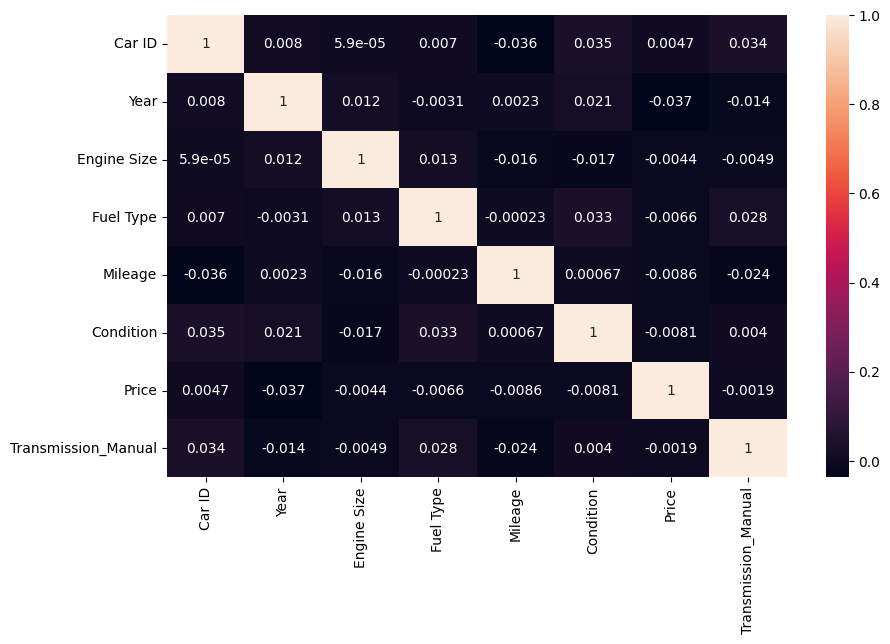

In [20]:
# Data Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [21]:
df.isnull().sum()

Car ID                 0
Brand                  0
Year                   0
Engine Size            0
Fuel Type              0
Mileage                0
Condition              0
Price                  0
Model                  0
Transmission_Manual    0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

C:\Users\PC\AppData\Local\Temp\ipykernel_10100\1827623327.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Price"])


<Axes: xlabel='Price', ylabel='Density'>

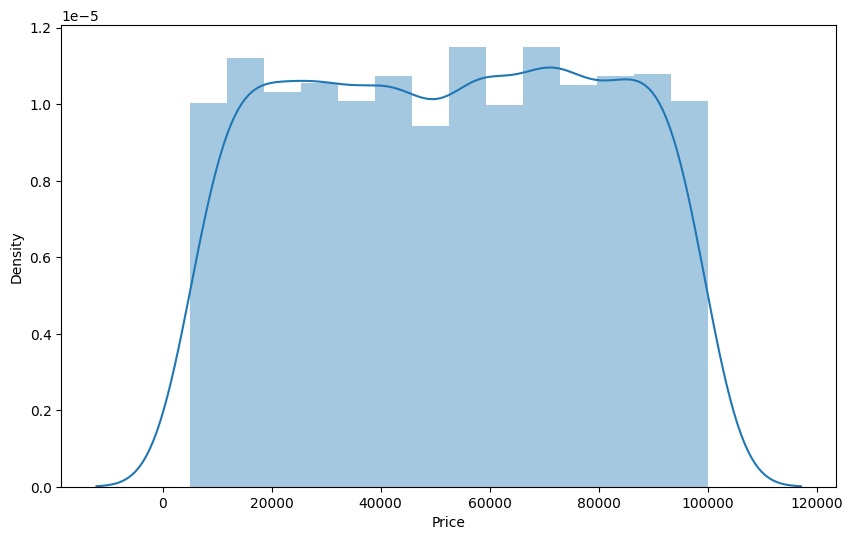

In [23]:
# Data Visualization for price distribution
plt.figure(figsize=(10, 6))
sns.distplot(df["Price"])

<Axes: xlabel='Year', ylabel='Price'>

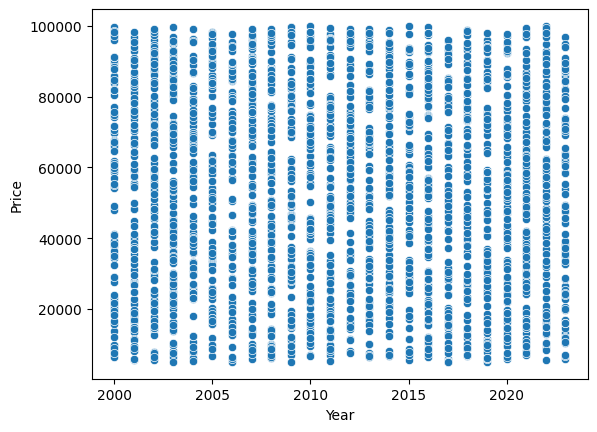

In [24]:
sns.scatterplot(data=df, x="Year", y="Price")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '2000'),
  Text(1, 0, '2001'),
  Text(2, 0, '2002'),
  Text(3, 0, '2003'),
  Text(4, 0, '2004'),
  Text(5, 0, '2005'),
  Text(6, 0, '2006'),
  Text(7, 0, '2007'),
  Text(8, 0, '2008'),
  Text(9, 0, '2009'),
  Text(10, 0, '2010'),
  Text(11, 0, '2011'),
  Text(12, 0, '2012'),
  Text(13, 0, '2013'),
  Text(14, 0, '2014'),
  Text(15, 0, '2015'),
  Text(16, 0, '2016'),
  Text(17, 0, '2017'),
  Text(18, 0, '2018'),
  Text(19, 0, '2019'),
  Text(20, 0, '2020'),
  Text(21, 0, '2021'),
  Text(22, 0, '2022'),
  Text(23, 0, '2023')])

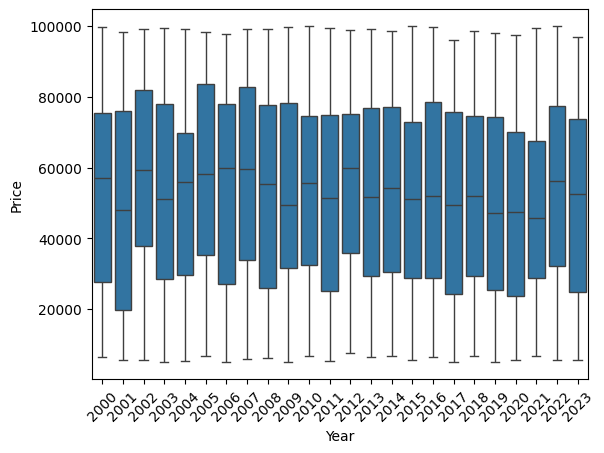

In [26]:
sns.boxplot(data=df, x="Year", y="Price")
plt.xticks(rotation=45)

<Axes: xlabel='Mileage', ylabel='Price'>

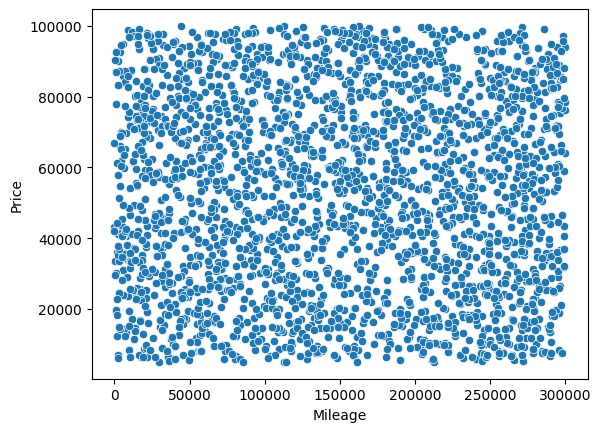

In [28]:
sns.scatterplot(data=df, x="Mileage", y="Price")

<Axes: xlabel='Mileage', ylabel='Price'>

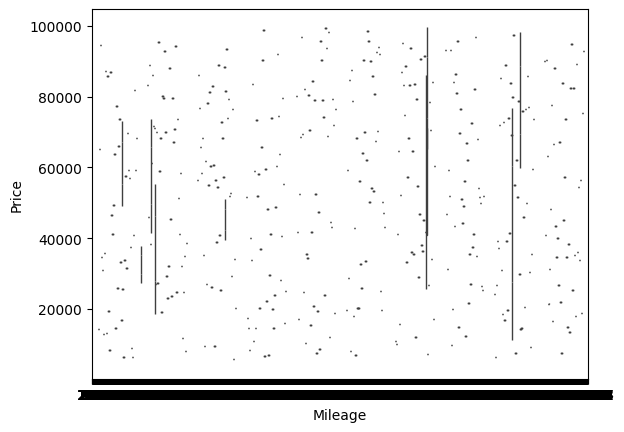

In [29]:
sns.boxplot(data=df, x="Mileage", y="Price")

### The model failed to find a relationship because the synthetic data lacks the covariance found in real-world markets.